# Feature Engineering

In this kernel, I have deeply explained all numeric features with visualization. Many of the features play a significant role to predict SalesPrice of home. There are also some features exist in data, which may not alone work, but if we concat that feature with other feature. It performs outstanding. 

I highly suggest checking out [this lernel](https://www.kaggle.com/bhavikapanara/how-to-detect-an-outlier)
to understand Outlier detection techniques.

    Let's load Libraries

In [1]:
from sklearn.preprocessing import LabelEncoder
from scipy.stats import norm, skew 
from scipy.special import boxcox1p
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', 100) 
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import os

In [2]:
train = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")

train.shape,test.shape

((1460, 81), (1459, 80))

    Let's get the list of numeric features.

In [3]:
num_feat = [col for col in train.columns if train[col].dtype != 'object']
print("Number of numeric feature in data :",len(num_feat))

Number of numeric feature in data : 38


# Data Analysis for one by one feature

In [4]:
def num_analysis(i=False, feat_name=False):
    
    if (i):
        feat = num_feat[i]
    
    elif (feat_name):
        feat = feat_name
        
    print("Feature: {}  & Correlation with target: {}".format(feat,train[feat].corr(train['SalePrice'])))
            
    fig=plt.figure(figsize=(20,4))

    ax=fig.add_subplot(1,3,1)
    ax.hist(train[feat])
    ax.set_title("train", fontsize = 20)
    ax.set_xlabel(feat,fontsize=20)
    ax.tick_params(labelsize=13)
    
    ax=fig.add_subplot(1,3,2)
    ax.scatter(train[feat],train['SalePrice'])
    ax.set_title(feat+" vs SalesPrice", fontsize = 20)
    ax.set_xlabel(feat,fontsize=20)
    ax.set_ylabel("SalesPrice",fontsize=20)
    ax.tick_params(labelsize=13)
    
    ax=fig.add_subplot(1,3,3)
    ax.hist(test[feat])
    ax.set_title("test", fontsize = 20)
    ax.set_xlabel(feat,fontsize=20)
    ax.tick_params(labelsize=13)
    
    plt.show()

Feature: MSSubClass  & Correlation with target: -0.08428413512659531


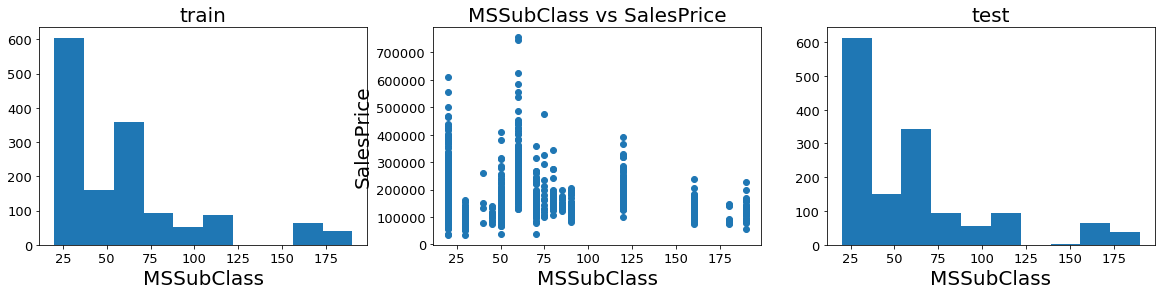

In [5]:
k=1
num_analysis(i = k)

Actually, MSSubClass feature is a categorical feature. To make this feature more senseful we would apply   a label encoding

Feature: MSSubClass  & Correlation with target: 0.049054897741599976


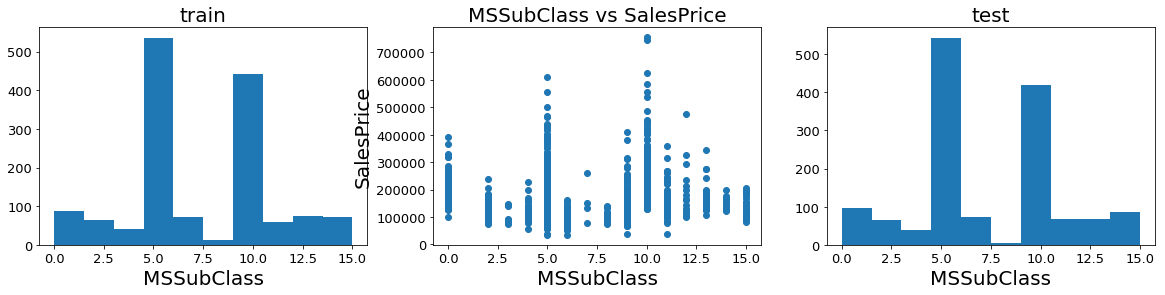

In [6]:
train['MSSubClass'] = train['MSSubClass'].apply(str)
test['MSSubClass'] = test['MSSubClass'].apply(str)

lbl = LabelEncoder() 
lbl.fit(list(train['MSSubClass'].values) + list(test['MSSubClass'].values)) 

train['MSSubClass'] = lbl.transform(list(train['MSSubClass'].values))
test['MSSubClass'] = lbl.transform(list(test['MSSubClass'].values))

num_analysis(feat_name='MSSubClass')

Feature: LotFrontage  & Correlation with target: 0.35179909657067804


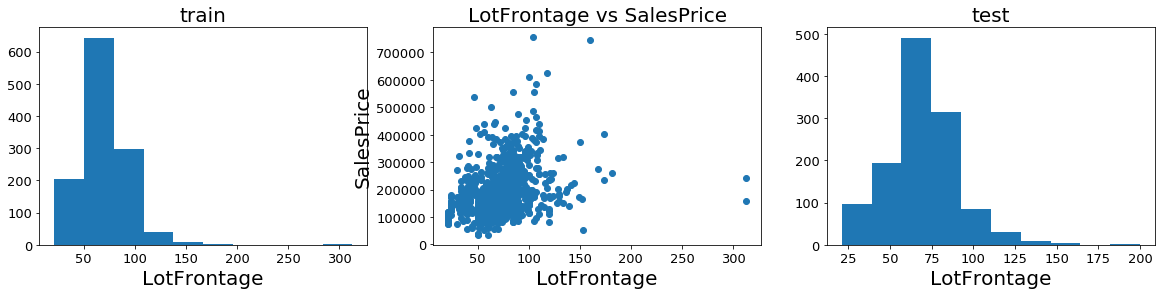

In [7]:
k= k +1
num_analysis(i = k)

Here, May be these two outlier exists with LotFrontage > 300 and SalesProce < 250000

Let's see the details of these two outlier

In [8]:
dff = train.loc[(train['LotFrontage'] >= 300) & (train['SalePrice'] < 200000)]
dff

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,10,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


    Let's find some helpful insights from this house.

    LotFrontage : 300 | LotArea:63887 | OverallQual:10 | BsmtQual:Ex | ExterQual:Ex | TotalBsmtSF:6110 | GrLivArea:5642 | KitchenQual:Ex | TotRmsAbvGrd:12 | GarageArea:1418 | PoolArea:480 | SaleType:New

    YearBuilt:2008  | YrSold:2008  (It's new House)

By Observing the house feature, can conclude that the house's Salesprice is low with respect to all of its features.

Feature: LotArea  & Correlation with target: 0.2638433538714056


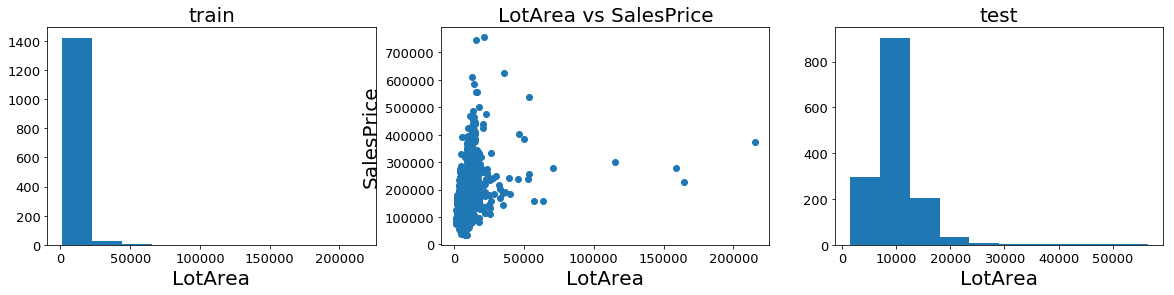

In [9]:
k = k+1
num_analysis(i = k)

    This feature hasn't uniform distribution. Let's check skewness of LotArea  feature

# Skewness & Kurtosis

Skewness is a measure of the symmetry in a distribution. 

A symmetrical dataset will have a skewness equal to 0.  So, a normal distribution will have a skewness of 0.   Skewness essentially measures the relative size of the two tails. 

If the skewness is between -0.5 and 0.5, the data are fairly symmetrical

If the skewness is between -1 and – 0.5 or between 0.5 and 1, the data are moderately skewed

If the skewness is less than -1 or greater than 1, the data are highly skewed

Kurtosis is a measure of the combined sizes of the two tails.  It measures the amount of probability in the tails.  

The value is often compared to the kurtosis of the normal distribution, which is equal to 3.  If the kurtosis is greater than 3, then the dataset has heavier tails than a normal distribution (more in the tails).  If the kurtosis is less than 3, then the dataset has lighter tails than a normal distribution (less in the tails).  

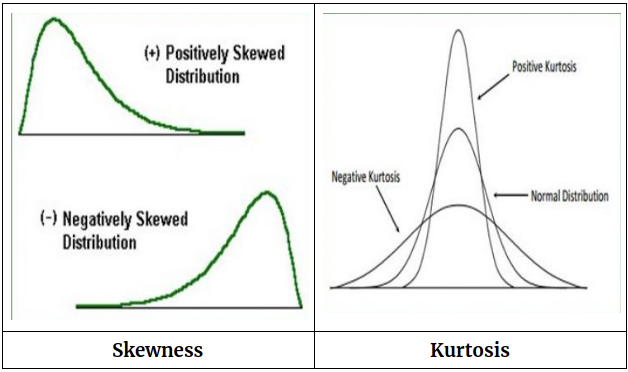

In [10]:
from IPython.display import Image
Image("../input/skew-img/skew_kurt.png")

In [11]:
print("Skewness: %f" % train['LotArea'].skew())
print("Kurtosis: %f" % train['LotArea'].kurt())

Skewness: 12.207688
Kurtosis: 203.243271


The distribution of LotArea feature is highly skewed.

So, we should apply logithmic function to  LotArea feature to make it less skeded. Let's do it.

Feature: LotArea  & Correlation with target: 0.3885283824240989


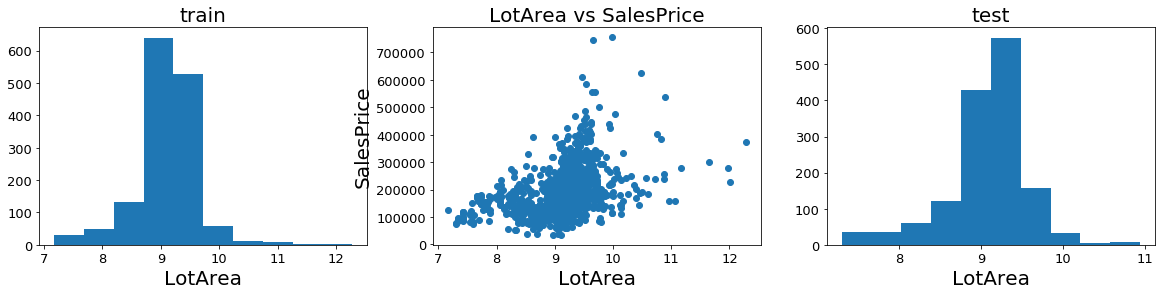

In [12]:
train["LotArea"] = np.log1p(train["LotArea"])
test["LotArea"] = np.log1p(test["LotArea"])
num_analysis(i = k)

    Now, It's look much better and also correaltion with SalesPrice(target) is also increased from  0.2638 to 0.3835.

Let's move to next feature 

Feature: OverallQual  & Correlation with target: 0.7909816005838044


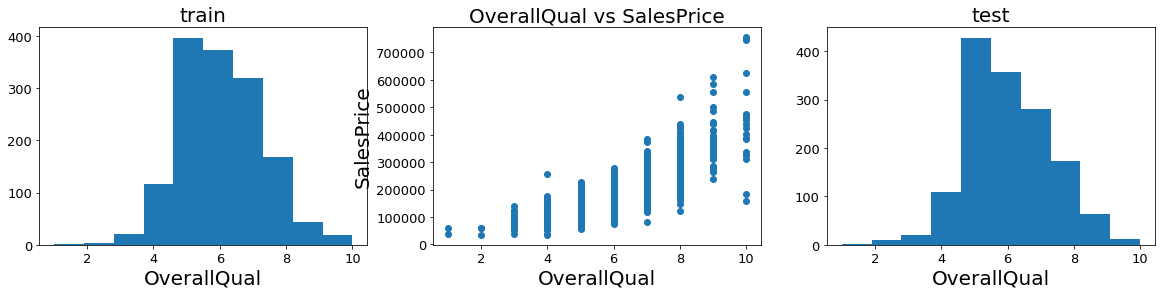

In [13]:
k = k + 1
num_analysis(i =k)

    OverallQual feature looks good as it has higher correaltion with taregt SalesPrice.

Next Feature:

Feature: OverallCond  & Correlation with target: -0.07785589404867803


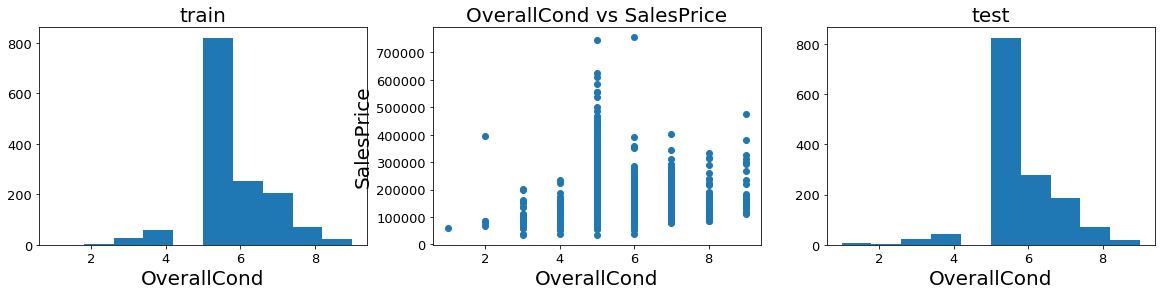

In [14]:
k = k+ 1
num_analysis(i=k)

    OverallQual: Rates the overall material and finish of the house

    OverallCond: Rates the overall condition of the house

    OverallQual feature positivly correaltion with target variable SalesPrice. means higher OverallQual value of house sold at higher price. 
 
    But, OverallCond hasn't any relationship with target variable(SalesPrice). 

    Above scatter plot depicts that, some house with OverallCond value 5 has sold at higher price. Hence, this feature alone isn't helpful.

In [15]:
train.loc[(train['OverallCond'] == 6) & (train['SalePrice'] > 600000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,10,RL,104.0,9.977481,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455,Unf,0,989,2444,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0,1,3,1,4,1,Ex,10,Typ,2,Ex,Attchd,1994.0,Fin,3,832,TA,TA,Y,382,50,0,0,0,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


    Let's make new feature of OverallCond & OverallQual

Feature: cond*qual  & Correlation with target: 0.5652938448019195


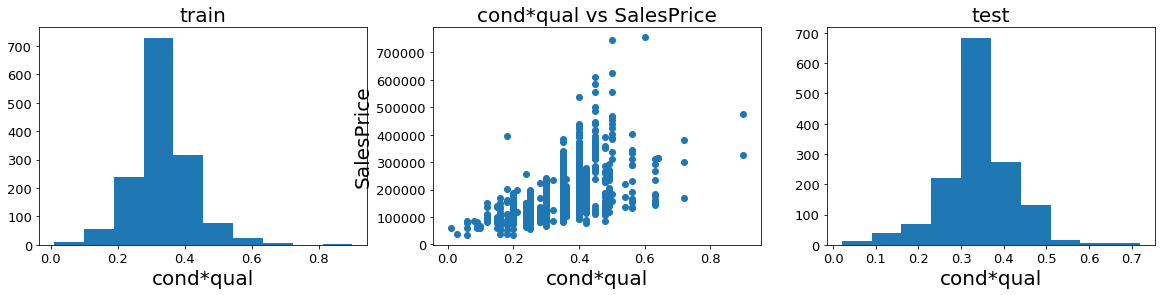

In [16]:
train['cond*qual'] = (train['OverallCond'] * train['OverallQual']) / 100.0
test['cond*qual'] = (test['OverallCond'] * test['OverallQual']) / 100.0

num_analysis(feat_name='cond*qual')

    This generated new feature is very useful. When I had trained the LightGBM model, this feature took the fist position in feature importance graph. trust me.. It works.

    Also, you should remove the OverallCond & OverallQual feature.

Feature: YearBuilt  & Correlation with target: 0.5228973328794969


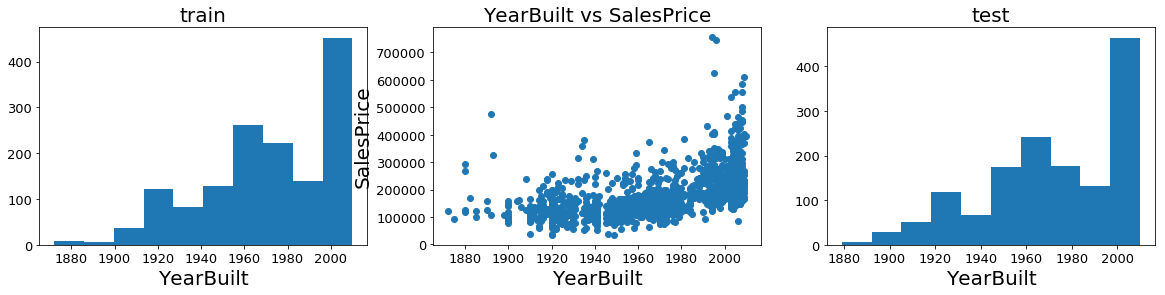

In [17]:
k = k+ 1
num_analysis(i=k)

    YearBuilt feature has somewhat linear relationship with SalesPrice.

    If you remember, the data also contains one feature YrSold (year sold). 
    Using these two feature YearBuilt and YrSold, we can generate new feature home age. It means how the house was old when it Sold.

In [18]:
train['home_age_when_sold'] = train['YrSold'] - train['YearBuilt']
test['home_age_when_sold'] = test['YrSold'] - test['YearBuilt']

Feature: home_age_when_sold  & Correlation with target: -0.523350417546816


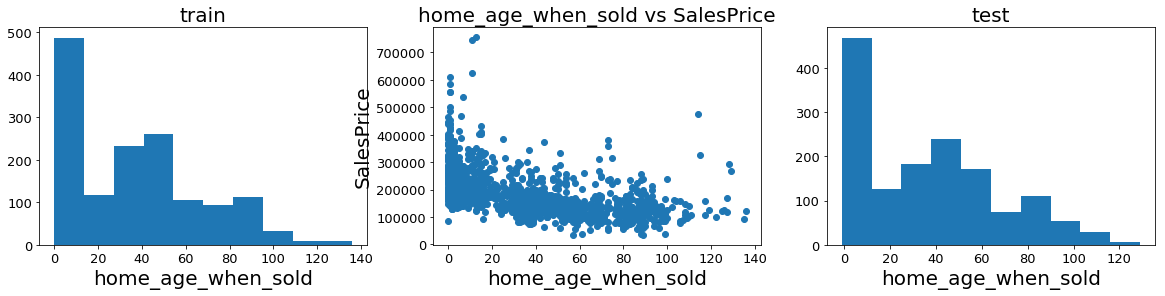

In [19]:
num_analysis(feat_name='home_age_when_sold')

    Now, you need to remove YrSold & YearBuilt features, as we have already create one feature using it.  

Let's move to next feature

Feature: YearRemodAdd  & Correlation with target: 0.5071009671113865


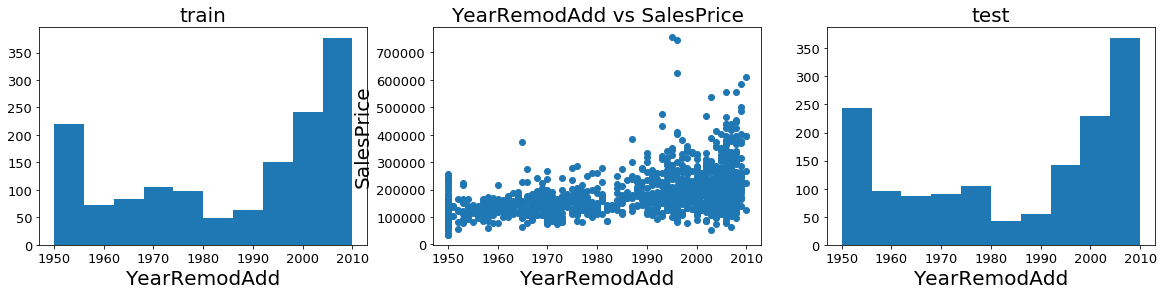

In [20]:
k = k +1 
num_analysis(i=k)

    We can also generate one new feature using YearRemodAdd feature.

    YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)

    new_feature is Home age after renovation

In [21]:
train['after_remodel_home_age_when_sold'] = train['YrSold'] - train['YearRemodAdd']
test['after_remodel_home_age_when_sold'] = test['YrSold'] - test['YearRemodAdd']

Feature: after_remodel_home_age_when_sold  & Correlation with target: -0.5090787380156292


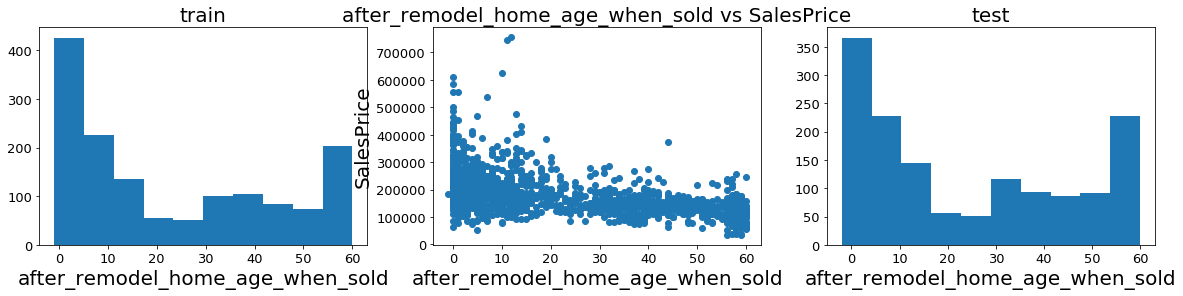

In [22]:
num_analysis(feat_name='after_remodel_home_age_when_sold')

    If you use this new feature, you must remove YearRemodAdd feature. Otherwise It create redundancy.

Next Feature:

Feature: MasVnrArea  & Correlation with target: 0.4774930470957163


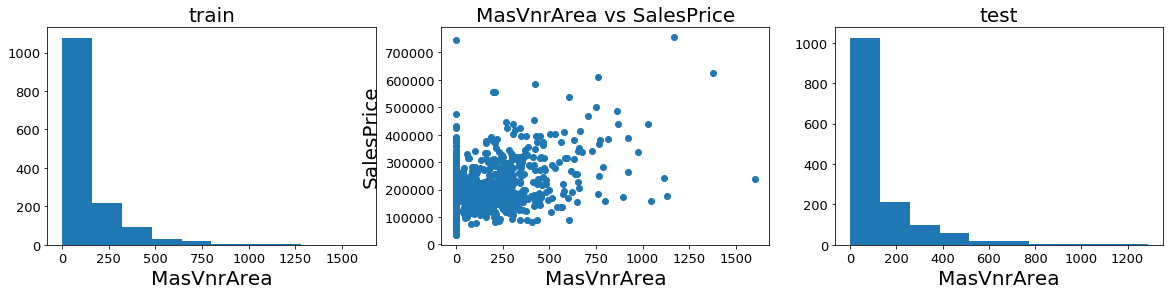

In [23]:
k = k + 1
num_analysis(i=k)

In [24]:
print("Skewness: %f" % train['MasVnrArea'].skew())
print("Kurtosis: %f" % train['MasVnrArea'].kurt())

Skewness: 2.669084
Kurtosis: 10.082417


Feature: MasVnrArea  & Correlation with target: 0.4109443027312646


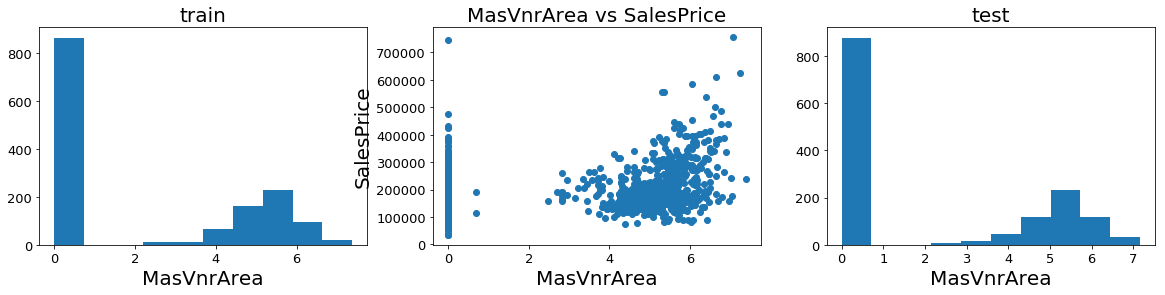

In [25]:
train["MasVnrArea"] = np.log1p(train["MasVnrArea"])
test["MasVnrArea"] = np.log1p(test["MasVnrArea"])
num_analysis(i = k)

Feature: BsmtFinSF1  & Correlation with target: 0.3864198062421532


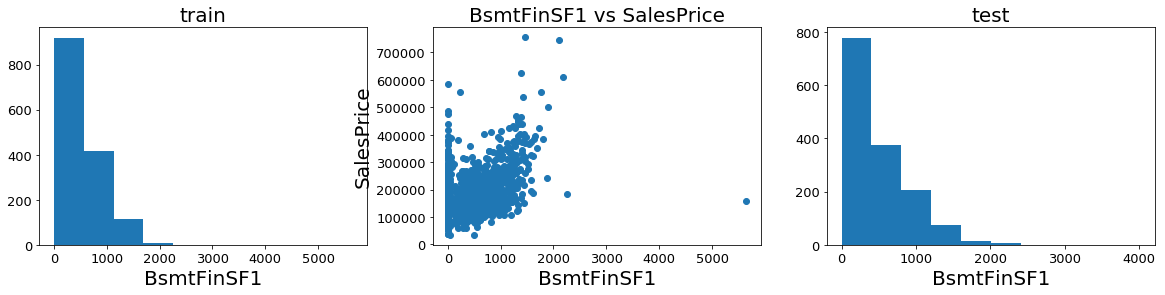

In [26]:
k = k +1
num_analysis(i=k)

    BsmtFinSF1: Type 1 (basement) finished square feet

    In train data,  one home has more are of basement and sold at low price.
    Let's see details of the this feature

In [27]:
train.loc[(train['BsmtFinSF1'] > 4500) & (train['SalePrice'] < 200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold
1298,1299,10,RL,313.0,11.064887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,6.680855,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000,0.5,0,0


    Again the same home (index = 1298).
    
    we have already discover this home above.

Feature: BsmtFinSF2  & Correlation with target: -0.011378121450215125


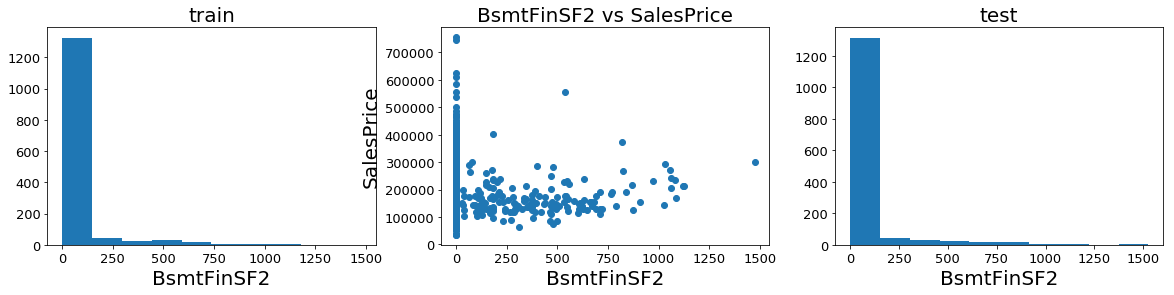

In [28]:
k = k +1
num_analysis(i=k)

    There are lots of home with 0 value of BsmtFinSF2 feature.

In [29]:
print("Number of home which has BsmtFinSF2 in train : {}%" .format(((train['BsmtFinSF2']!=0).sum() / train.shape[0])*100))
print("Number of home which has BsmtFinSF2 in test  : {}%" .format(((test['BsmtFinSF2']!=0).sum() / test.shape[0])*100))

Number of home which has BsmtFinSF2 in train : 11.438356164383562%
Number of home which has BsmtFinSF2 in test  : 12.405757368060314%


    BsmtFinSF2 feature is not looking useful.
    
    We could make new feature using BsmtFinSF1 & BsmtFinSF2
    
    BsmtFinSF1: Type 1 finished square feet
    BsmtFinSF2: Type 2 finished square feet

Feature: BsmtFinSF1+BsmtFinSF2  & Correlation with target: 0.36632769193495623


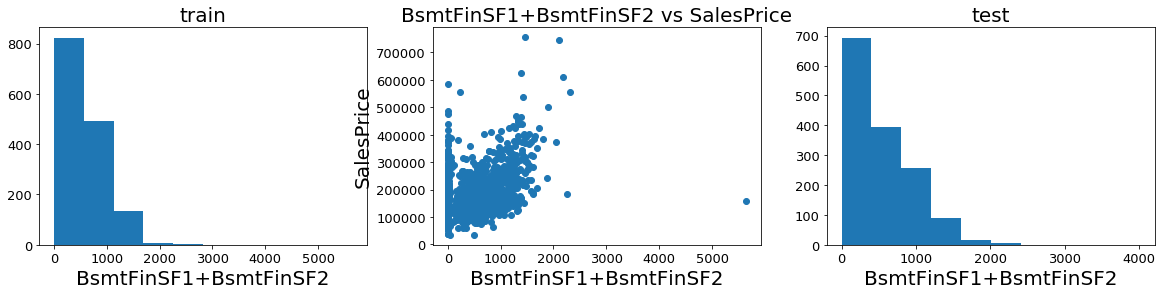

In [30]:
train['BsmtFinSF1+BsmtFinSF2'] = train['BsmtFinSF1'] + train['BsmtFinSF2']
test['BsmtFinSF1+BsmtFinSF2'] = test['BsmtFinSF1'] + test['BsmtFinSF2']

num_analysis(feat_name='BsmtFinSF1+BsmtFinSF2')

    If we use this new feature, we must remove BsmtFinSF1 & BsmtFinSF2 feature as we have already use it.

Feature: BsmtUnfSF  & Correlation with target: 0.21447910554696892


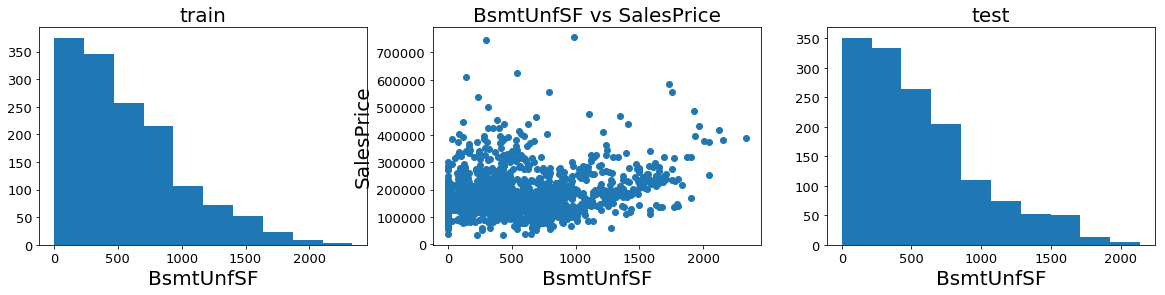

In [31]:
k = k +1
num_analysis(i=k)

Feature: TotalBsmtSF  & Correlation with target: 0.6135805515591956


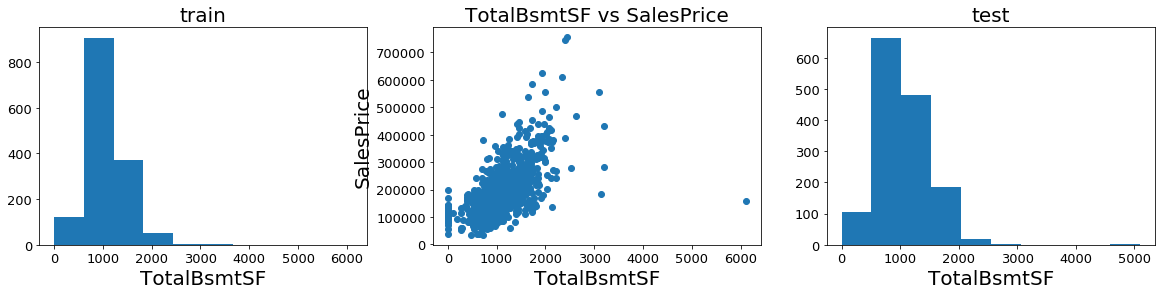

In [32]:
k = k +1
num_analysis(i=k)

    One Outlier may be detected with TotalBsmtSF>6000 and SalesPrice is low. Let's see details of that home

In [33]:
train.loc[(train['TotalBsmtSF']>=6000 ) &(train['SalePrice'] < 200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2
1298,1299,10,RL,313.0,11.064887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,6.680855,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000,0.5,0,0,5644


    Again the same house (index = 1298)
    We already discover this home above.

Feature: 1stFlrSF  & Correlation with target: 0.6058521846919147


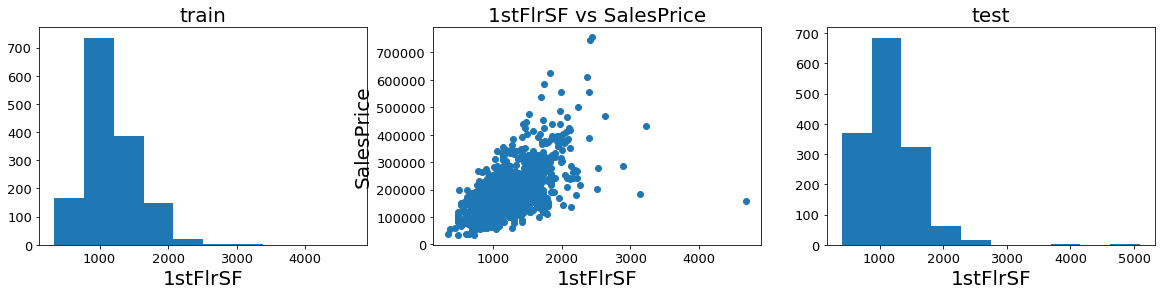

In [34]:
k = k +1
num_analysis(i=k)

    1stFlrSF: First Floor square feet

    Outlier exists. 1stFlrSF value > 4000 & salesPrice < 100000

    Let's find it

In [35]:
train.loc[(train['1stFlrSF'] >= 4000) & (train['SalePrice'] < 200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2
1298,1299,10,RL,313.0,11.064887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,6.680855,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000,0.5,0,0,5644


    One more time index=1298 home detected as outlier

Feature: 2ndFlrSF  & Correlation with target: 0.3193338028320681


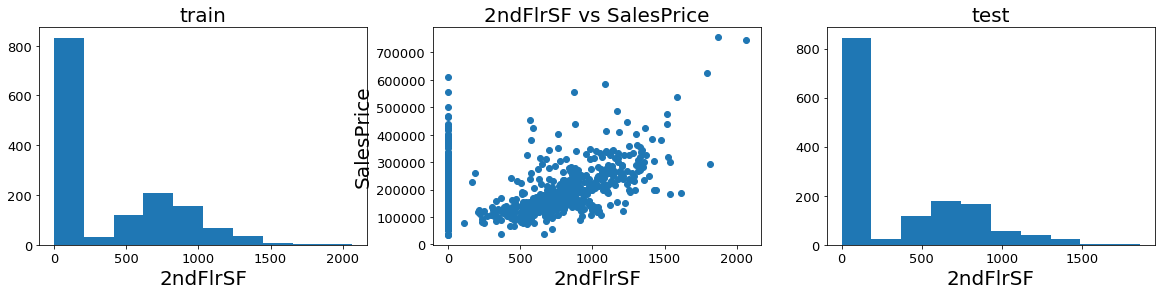

In [36]:
k = k +1
num_analysis(i=k)

    2ndFlrSF feature is linearly correlation with target SalesPrice.
    
    Using 1stFlrSF, 2ndFlrSF and TotalBsmtSF features, we would generate new feature total_SF
    
    TotalBsmtSF: Total square feet of basement area
    1stFlrSF: First Floor square feet
    2ndFlrSF: Second floor square feet

Feature: TotalSF  & Correlation with target: 0.7822600527979846


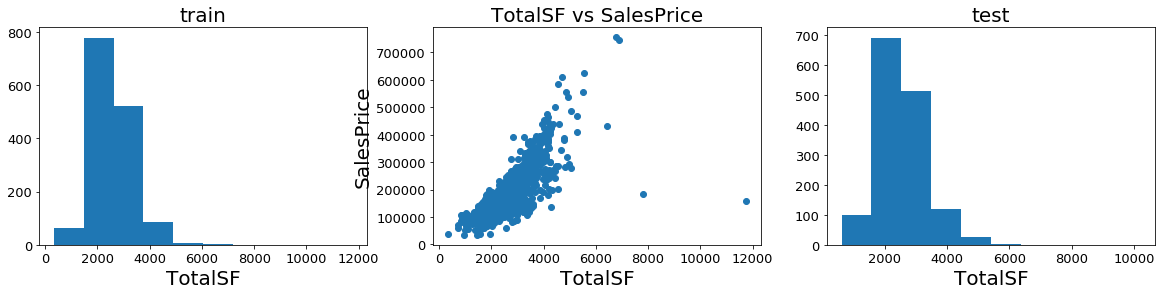

In [37]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

num_analysis(feat_name='TotalSF')

    this created new TotalSF feature is highly correalted with Salesprice. Great!

Feature: LowQualFinSF  & Correlation with target: -0.02560613000067959


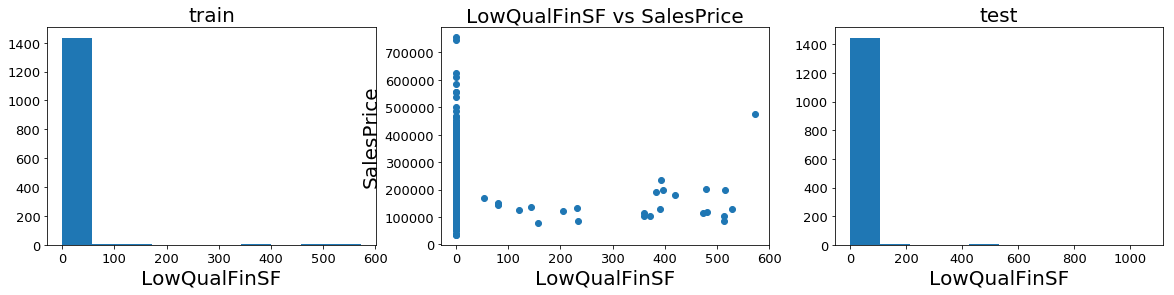

In [38]:
k = k +1
num_analysis(i=k)

    This feature LowQualFinSF alone may not be useful, as many of house doesn't have value for this feature. But, we could use this feature with another feature and create new feature.

Feature: GrLivArea  & Correlation with target: 0.7086244776126523


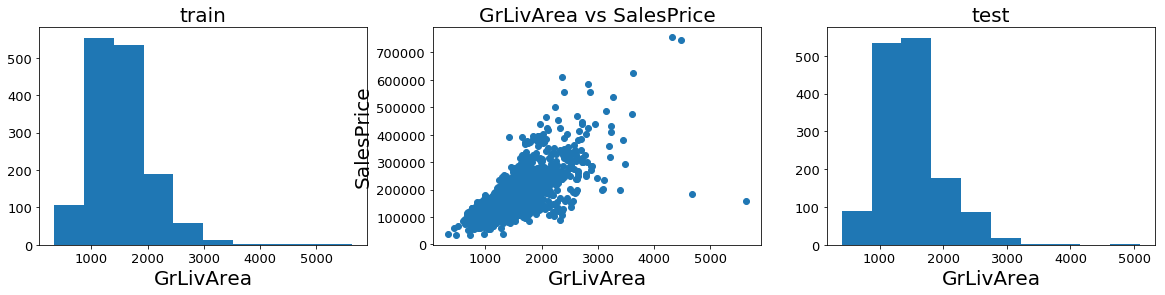

In [39]:
k = k +1
num_analysis(i=k)

GrLivArea: Above grade (ground) living area square feet

From above plot, there may be a Outlier exists with GrLivArea > 5000 and salesPrice is too low. 

Let's find it.

In [40]:
train.loc[(train['GrLivArea'] >= 5000) & (train['SalePrice'] < 200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2,TotalSF
1298,1299,10,RL,313.0,11.064887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,6.680855,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000,0.5,0,0,5644,11752


    again same house detected (index=1298), which we have already discovered ambiguity above.

Feature: BsmtFullBath  & Correlation with target: 0.22712223313149382


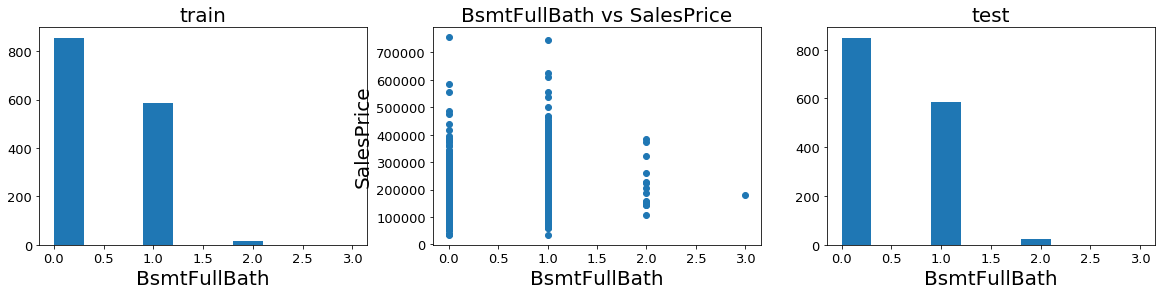

In [41]:
k = k +1
num_analysis(i=k)

Feature: BsmtHalfBath  & Correlation with target: -0.016844154297359016


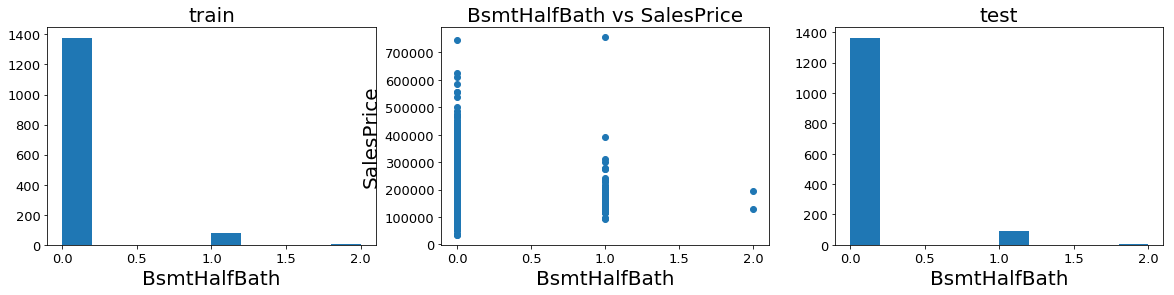

In [42]:
k = k +1
num_analysis(i=k)

Feature: FullBath  & Correlation with target: 0.5606637627484449


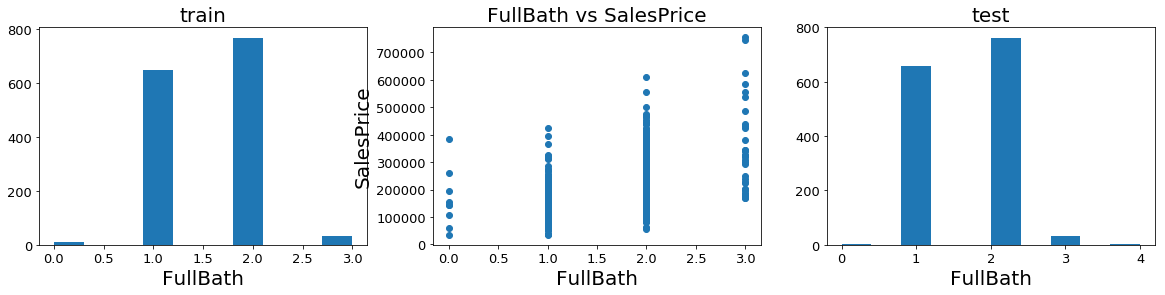

In [43]:
k = k +1
num_analysis(i=k)

Feature: HalfBath  & Correlation with target: 0.2841076755947831


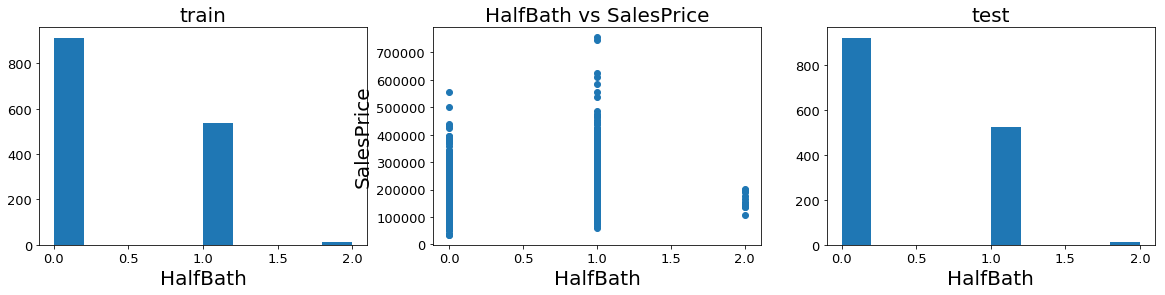

In [44]:
k = k +1
num_analysis(i=k)

    we can generate one new feature using these all bathoom related features.
    
    BsmtFullBath: Basement full bathrooms

    BsmtHalfBath: Basement half bathrooms

    FullBath: Full bathrooms above grade

    HalfBath: Half baths above grade

Feature: Total_Bathrooms  & Correlation with target: 0.6317310679319873


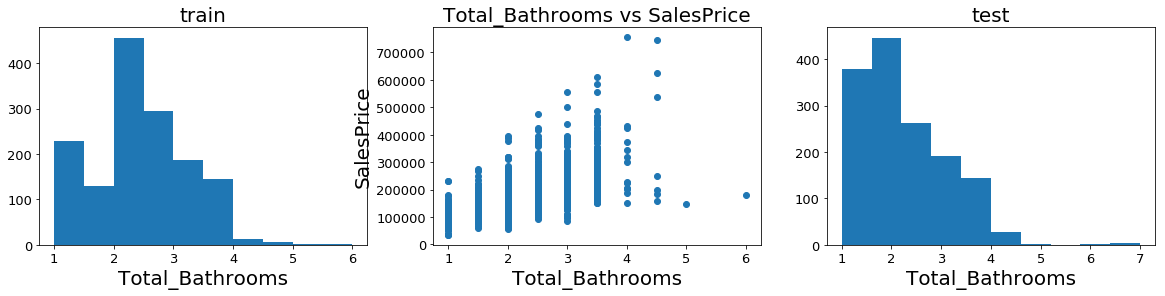

In [45]:
train['Total_Bathrooms'] = (train['FullBath'] + (0.5 * train['HalfBath']) + train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath']))
test['Total_Bathrooms'] = (test['FullBath'] + (0.5 * test['HalfBath']) + test['BsmtFullBath'] + (0.5 * test['BsmtHalfBath']))

num_analysis(feat_name='Total_Bathrooms')

    This new generated Total_Bathrooms feature has good correlation with target Salesprice feature.

Feature: BedroomAbvGr  & Correlation with target: 0.16821315430073988


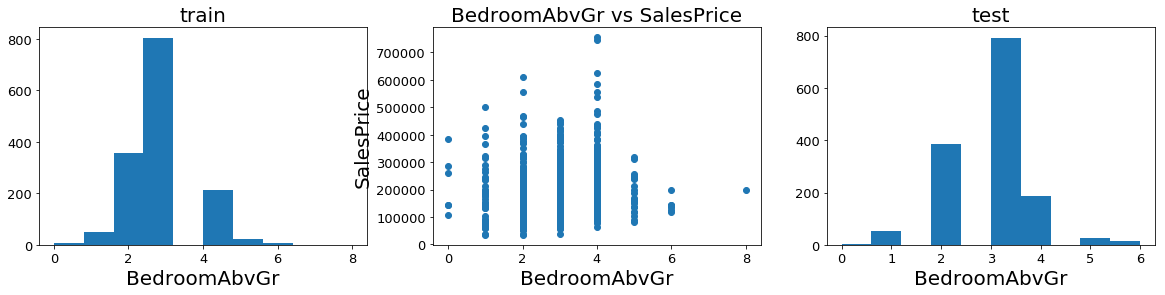

In [46]:
k = k +1
num_analysis(i=k)

Feature: KitchenAbvGr  & Correlation with target: -0.13590737084214122


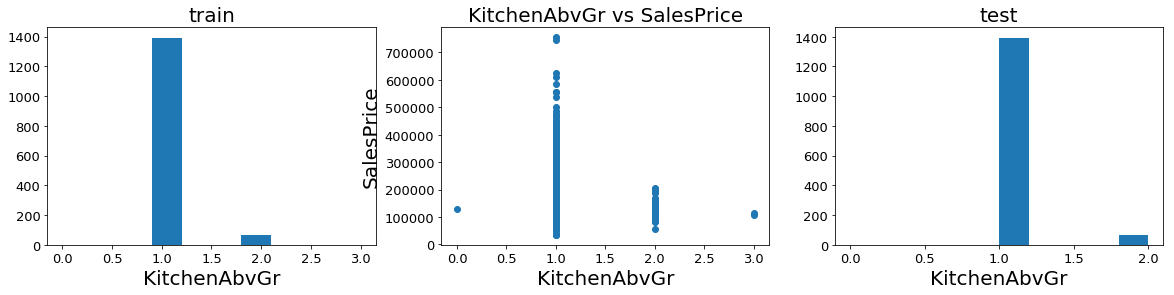

In [47]:
k = k +1
num_analysis(i=k)

    Something Interesting!!

    There is a house in train data which have 3 kitchens and its Sold at very low price.

    Let's find that house

In [48]:
train.loc[(train['KitchenAbvGr'] == 3) & (train['SalePrice'] < 150000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2,TotalSF,Total_Bathrooms
48,49,4,RM,33.0,8.402231,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,2fmCon,2Story,4,5,1920,2008,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,736,736,GasA,Gd,Y,SBrkr,736,716,0,1452,0,0,2,0,2,3,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,102,0,0,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000,0.20,89,1,0,2188,2.0
809,810,12,RM,90.0,8.999743,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Norm,Norm,1Fam,2.5Unf,5,5,1898,1965,Hip,CompShg,AsbShng,AsbShng,None,0.0,TA,TA,PConc,TA,TA,No,Unf,0,Unf,0,849,849,GasA,TA,N,FuseA,1075,1063,0,2138,0,0,2,0,2,3,TA,11,Typ,0,NaN,Detchd,1910.0,Unf,2,360,Fa,Po,N,40,156,0,0,0,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000,0.25,111,44,0,2987,2.0


    SalesPrice of these house are less as they are too old.

Feature: TotRmsAbvGrd  & Correlation with target: 0.5337231555820282


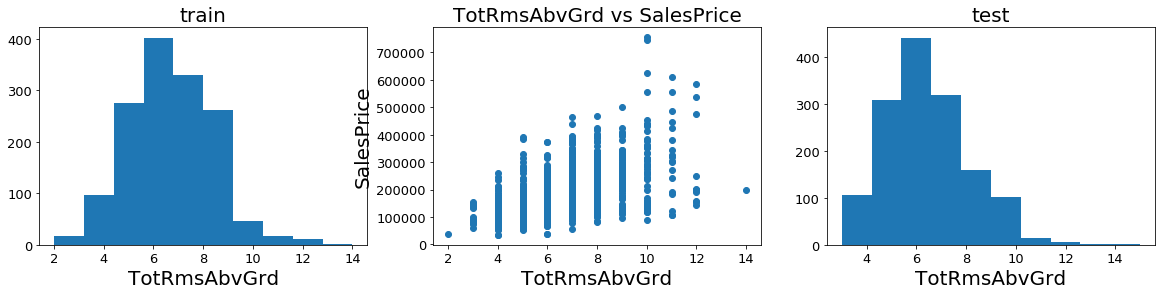

In [49]:
k = k +1
num_analysis(i=k)

    This feature has uniform distribution. It's good

    In train data, one house exist with 14 total bedrooms. Let's see all details of this home.

In [50]:
train.loc[(train['TotRmsAbvGrd'] == 14) & (train['SalePrice'] <= 200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2,TotalSF,Total_Bathrooms
635,636,4,RH,60.0,9.296243,Pave,Pave,Reg,Bnk,AllPub,Inside,Gtl,SWISU,Feedr,Norm,2fmCon,2.5Fin,6,7,1914,1995,Hip,CompShg,VinylSd,VinylSd,None,0.0,Fa,TA,CBlock,TA,Fa,No,LwQ,256,Unf,0,1184,1440,GasA,Ex,Y,FuseA,1440,1440,515,3395,0,0,2,0,8,2,Fa,14,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,110,0,0,0,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000,0.42,93,12,256,4320,2.0


    This home is also too old when it sold (93 year old home)

Feature: Fireplaces  & Correlation with target: 0.46692883675152724


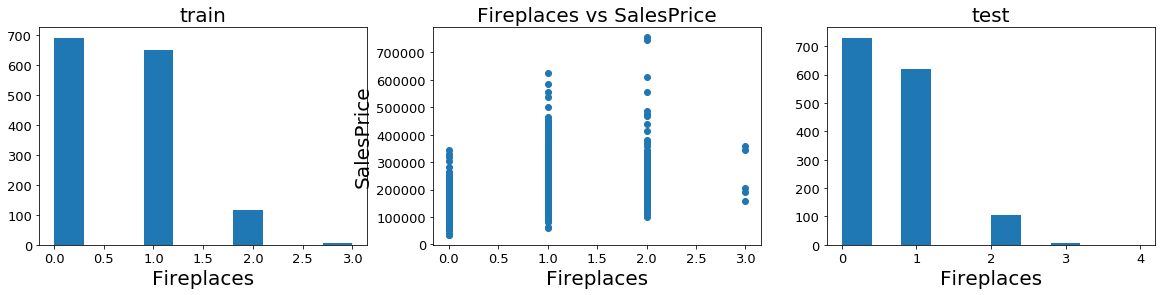

In [51]:
k = k +1
num_analysis(i=k)

    Observing Graph plot, there are such home exists with 3 fireplaces and there SalesPrice not much.

    Let's see these home

In [52]:
train.loc[(train['Fireplaces'] == 3)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2,TotalSF,Total_Bathrooms
166,167,5,RL,NaN,9.278840,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,ClearCr,Norm,Norm,1Fam,1Story,5,5,1955,1993,Hip,CompShg,Wd Sdng,Wd Sdng,None,0.000000,Gd,TA,CBlock,TA,TA,No,LwQ,379,BLQ,768,470,1617,GasA,Ex,Y,FuseA,1867,0,0,1867,1,0,1,0,2,1,TA,7,Typ,3,Gd,Attchd,1955.0,Fin,1,303,TA,TA,Y,476,0,0,0,142,0,NaN,GdWo,NaN,0,11,2009,COD,Normal,190000,0.25,54,16,1147,3484,2.0
309,310,5,RL,90.0,9.423757,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,9,5,2003,2004,Gable,CompShg,VinylSd,VinylSd,None,0.000000,Gd,TA,PConc,Ex,TA,Gd,GLQ,1274,Unf,0,622,1896,GasA,Ex,Y,SBrkr,1944,0,0,1944,1,0,2,0,3,1,Ex,8,Typ,3,Ex,Attchd,2003.0,Fin,3,708,TA,TA,Y,208,175,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,360000,0.45,3,2,1274,3840,3.0
605,606,10,RL,85.0,9.517899,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,2Story,7,6,1965,1990,Gable,CompShg,HdBoard,HdBoard,BrkFace,5.176150,TA,TA,CBlock,TA,TA,No,BLQ,454,Unf,0,314,768,GasA,TA,Y,SBrkr,1186,800,0,1986,0,0,2,1,3,1,TA,7,Typ,3,Fa,Attchd,1965.0,Unf,2,486,TA,TA,Y,0,42,0,0,189,0,NaN,NaN,NaN,0,10,2009,WD,Normal,205000,0.42,44,19,454,2754,2.5
642,643,13,RL,75.0,9.536834,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,SLvl,8,7,1972,1995,Gable,CompShg,Plywood,Wd Sdng,None,0.000000,Gd,TA,CBlock,Gd,TA,Gd,GLQ,1410,Unf,0,542,1952,GasA,Gd,Y,SBrkr,2000,704,0,2704,1,0,2,1,4,1,Ex,9,Typ,3,TA,Attchd,1972.0,Fin,2,538,TA,TA,Y,269,111,0,0,0,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal,345000,0.56,37,14,1410,4656,3.5
1298,1299,10,RL,313.0,11.064887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,6.680855,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000,0.50,0,0,5644,11752,4.5


    There are such 5 home exists.

    means, number of Fireplace is alone not important, it's also depends on the quality of the Fireplace.

    So, we can generate one new feature from these two feature Fireplaces & FireplaceQu, which make more sense.

    Let's see the feature FireplaceQu(It's categorical) feature

FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace

    To make it more senseful, we should encode this catecorical feature in descending order

    like, Ex:5 | Gd:4 | TA:3 | Fa:2 | Po:1 | NA:0

    Let's check missing values in these two feature.

In [53]:
print("Missing value count in Fireplaces  :",train['Fireplaces'].isna().sum())
print("Missing value count in FireplaceQu :",train['FireplaceQu'].isna().sum())

Missing value count in Fireplaces  : 0
Missing value count in FireplaceQu : 690


    Let's fill missing value in FireplaceQu with NA.

In [54]:
train["FireplaceQu"] = train["FireplaceQu"].fillna("NA")
test["FireplaceQu"] = test["FireplaceQu"].fillna("NA")

In [55]:
def FireplaceQu_encode(x):
    if x=='Ex':
        return 5
    elif x=='Gd':
        return 4
    elif x == 'TA':
        return 3
    elif x=='Fa':
        return 2
    elif x=='Po':
        return 1
    elif x=='NA':
        return 0

In [56]:
train['FireplaceQu'] = train['FireplaceQu'].apply(lambda x: FireplaceQu_encode(x))
test['FireplaceQu'] = test['FireplaceQu'].apply(lambda x: FireplaceQu_encode(x))

Feature: FireplaceQu  & Correlation with target: 0.5204376059504016


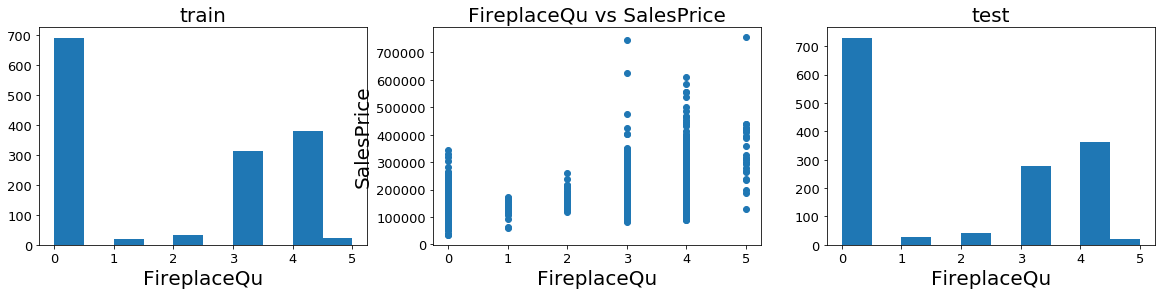

In [57]:
num_analysis(feat_name='FireplaceQu')

# Generate New Feature

In [58]:
train['FirePlace*FireplaceQu'] = train['Fireplaces']*train['FireplaceQu']
test['FirePlace*FireplaceQu'] = test['Fireplaces']*test['FireplaceQu']

Feature: FirePlace*FireplaceQu  & Correlation with target: 0.5100430093768966


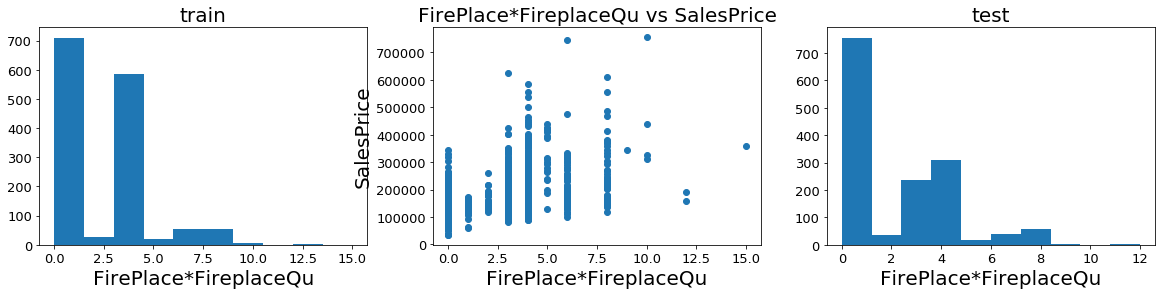

In [59]:
num_analysis(feat_name='FirePlace*FireplaceQu')

Feature: GarageYrBlt  & Correlation with target: 0.48636167748786097


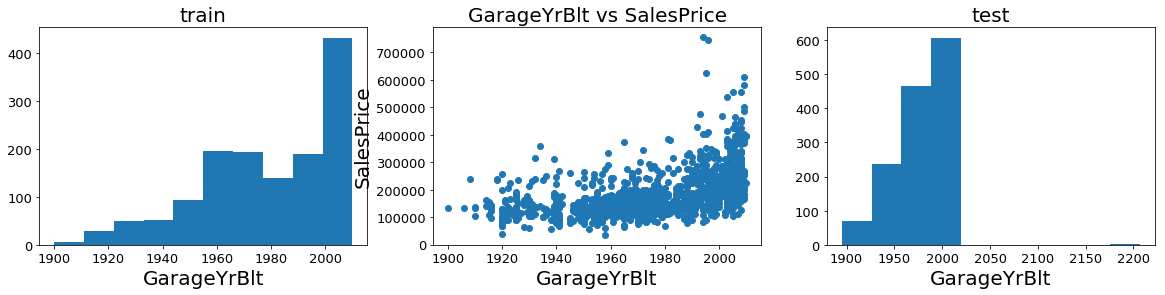

In [60]:
k = k +1
num_analysis(i=k)

    Something look surprise in histogram of test data.

    There is a home which GarageYrBlt value > 2100

    Let's see deatils of it

In [61]:
test.loc[(test['GarageYrBlt'] >= 2100)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2,TotalSF,Total_Bathrooms,FirePlace*FireplaceQu
1132,2593,5,RL,68.0,9.02389,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,8,5,2006,2007,Hip,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,Av,GLQ,583.0,Unf,0.0,963.0,1546.0,GasA,Ex,Y,SBrkr,1564,0,0,1564,0.0,0.0,2,0,2,1,Ex,6,Typ,1,4,Attchd,2207.0,RFn,2.0,502.0,TA,TA,Y,132,0,0,0,0,0,NaN,NaN,NaN,0,9,2007,New,Partial,0.4,1,0,583.0,3110.0,2.0,4


# one more outlier Detected

    this home details says, Garage was built in year 2207... Not possible at all.

Feature: GarageCars  & Correlation with target: 0.6404091972583529


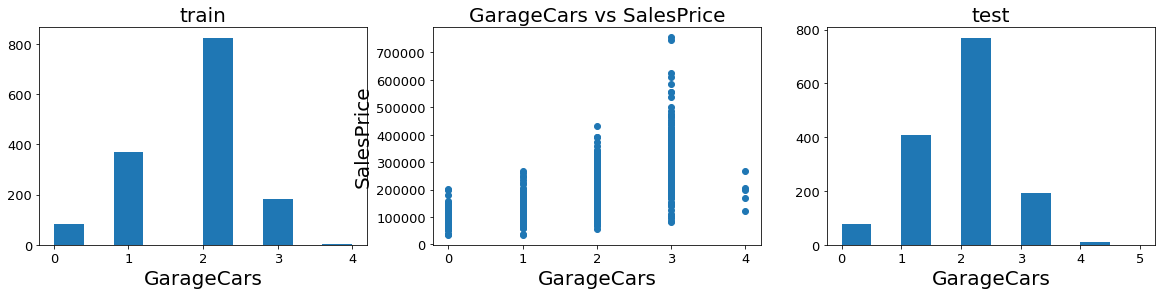

In [62]:
k = k +1
num_analysis(i=k)

    GarageCars: Size of garage in car capacity
    It's also helpful feature

Feature: GarageArea  & Correlation with target: 0.6234314389183618


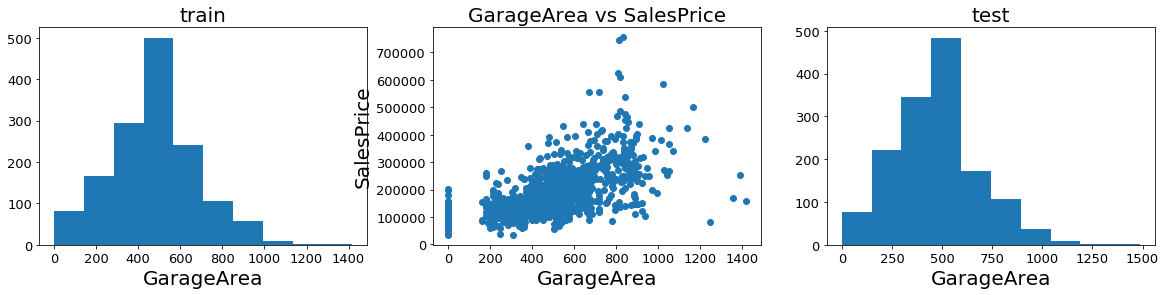

In [63]:
k = k +1
num_analysis(i=k)

    GarageArea feature look uniform distribution and linearly correaltion with target SalesPrice.

Feature: WoodDeckSF  & Correlation with target: 0.3244134445681294


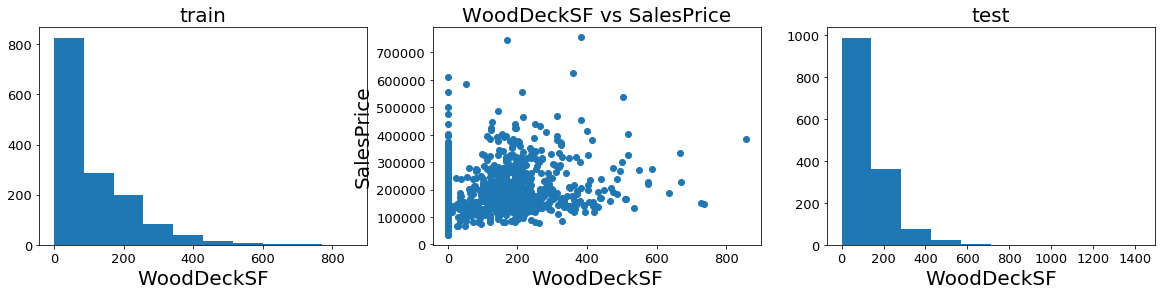

In [64]:
k = k +1
num_analysis(i=k)

Feature: OpenPorchSF  & Correlation with target: 0.3158562271160555


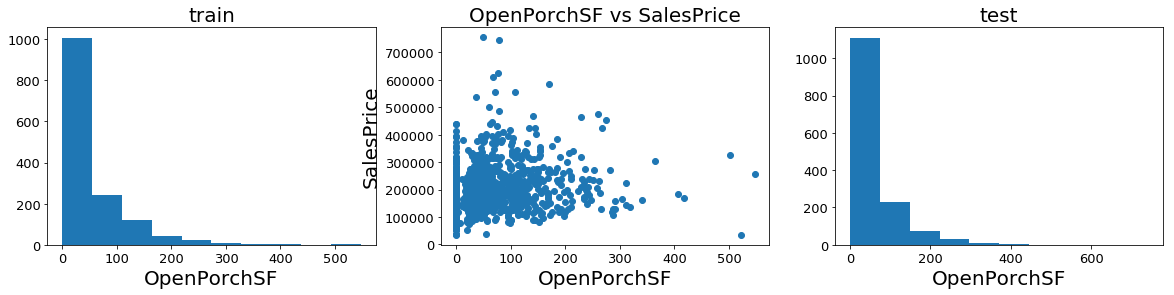

In [65]:
k = k +1
num_analysis(i=k)

Feature: EnclosedPorch  & Correlation with target: -0.12857795792595653


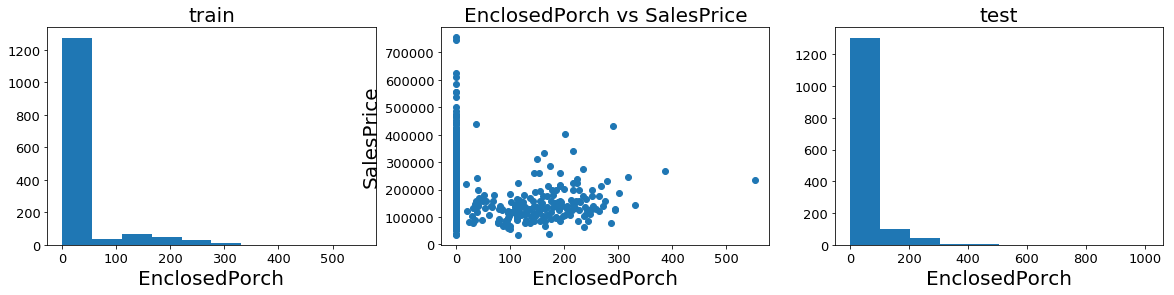

In [66]:
k = k +1
num_analysis(i=k)

Feature: 3SsnPorch  & Correlation with target: 0.04458366533574846


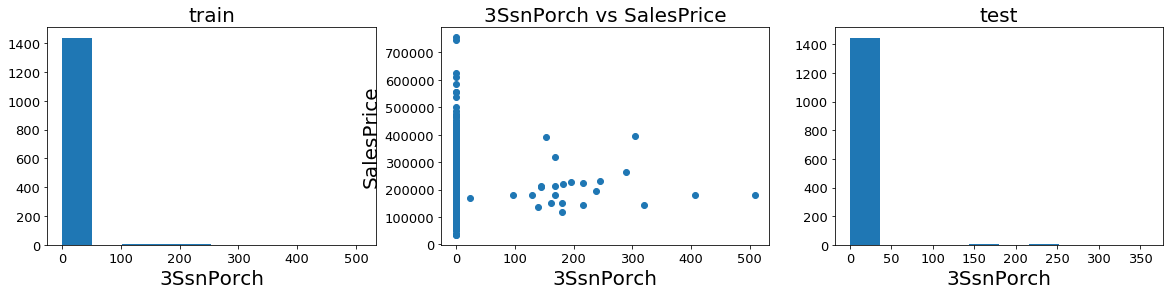

In [67]:
k = k +1
num_analysis(i=k)

Feature: ScreenPorch  & Correlation with target: 0.11144657114291105


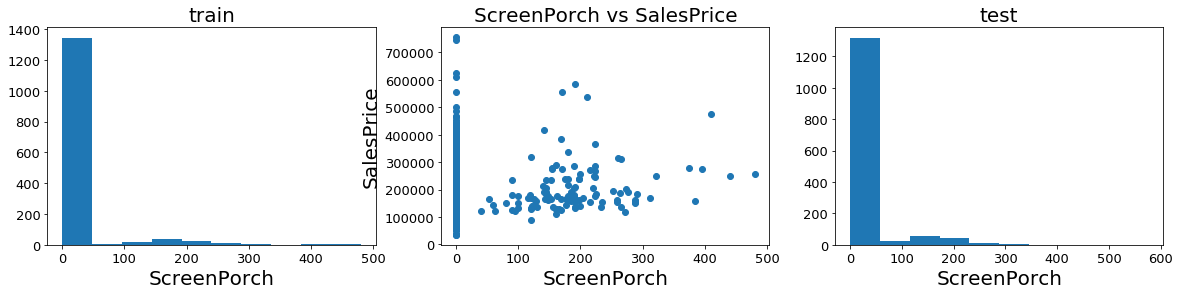

In [68]:
k = k +1
num_analysis(i=k)

    Let's create one combined feature "total_porch_area"

Feature: total_porch_area  & Correlation with target: 0.1957389407838354


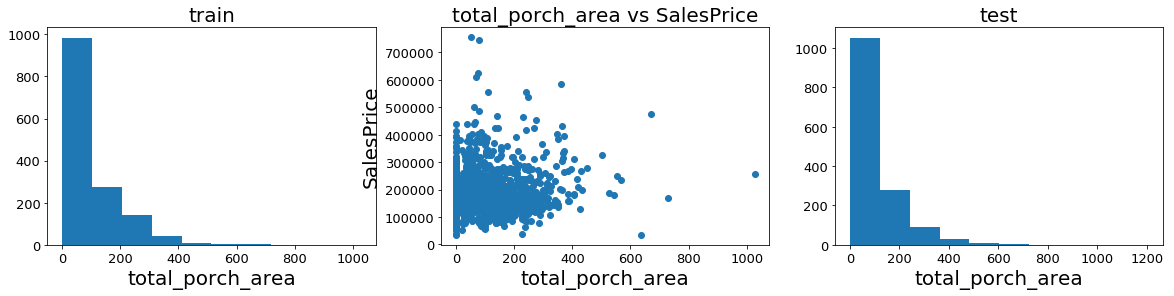

In [69]:
train['total_porch_area'] = train['OpenPorchSF'] + train['EnclosedPorch'] + train['3SsnPorch'] + train['ScreenPorch']
test['total_porch_area'] = test['OpenPorchSF'] + test['EnclosedPorch'] + test['3SsnPorch'] + test['ScreenPorch']

num_analysis(feat_name='total_porch_area')

Feature: PoolArea  & Correlation with target: 0.09240354949187321


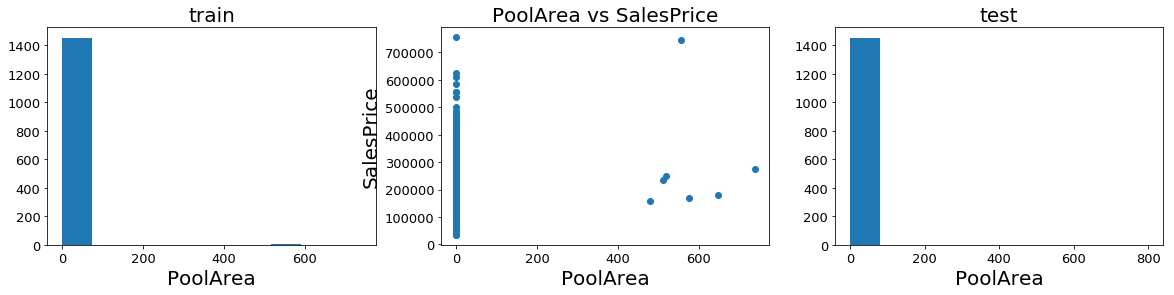

In [70]:
k = k +1
num_analysis(i=k)

    Most of the home doesn't have pool.
    
    Let's check howmany house has pool in train & test

In [71]:
print("Number of house which has Pool in train :",(train['PoolArea'] != 0).sum())
print("Number of house which has Pool in test  :",(test['PoolArea'] != 0).sum())

Number of house which has Pool in train : 7
Number of house which has Pool in test  : 6


    You can discard this feature as 99% of home doesn't have pool

Feature: MiscVal  & Correlation with target: -0.02118957964030325


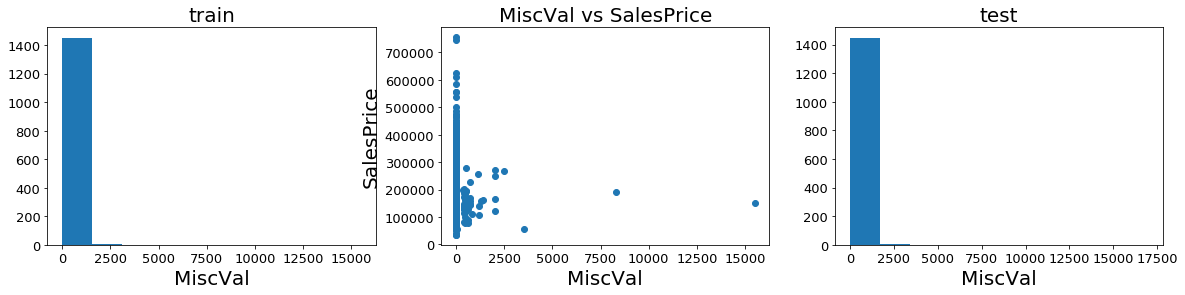

In [72]:
k = k +1
num_analysis(i=k)

    From histogram of test data, there is a home exist with more MiscVal value.

    Let's check test data

In [73]:
test.loc[test['MiscVal'] >= 15000]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,cond*qual,home_age_when_sold,after_remodel_home_age_when_sold,BsmtFinSF1+BsmtFinSF2,TotalSF,Total_Bathrooms,FirePlace*FireplaceQu,total_porch_area
1089,2550,5,RL,128.0,10.578751,Pave,NaN,IR1,Bnk,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,10,5,2008,2009,Hip,CompShg,CemntBd,CmentBd,Stone,7.110696,Ex,TA,PConc,Ex,TA,Gd,GLQ,4010.0,Unf,0.0,1085.0,5095.0,GasA,Ex,Y,SBrkr,5095,0,0,5095,1.0,1.0,2,1,2,1,Ex,15,Typ,2,4,Attchd,2008.0,Fin,3.0,1154.0,TA,TA,Y,546,484,0,0,0,0,NaN,NaN,NaN,17000,10,2007,New,Partial,0.5,-1,-2,4010.0,10190.0,4.0,8,484


# One more Outlier Detected

    the above home in test data have MiscVal cost $17000 and NaN at MiscFeature.

    In MiscFeature, NaN means No Miscellaneous feature

    How is it possible?


Feature: MoSold  & Correlation with target: 0.046432245223819384


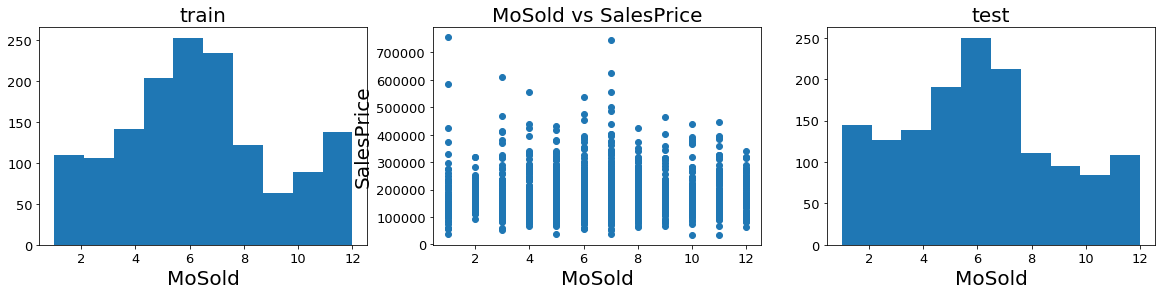

In [74]:
k = k +1
num_analysis(i=k)

    MoSold feature doesn't have any correaltion realation with Salesprice.

    You can remove this feature. not helpful for prediction

Feature: YrSold  & Correlation with target: -0.028922585168730378


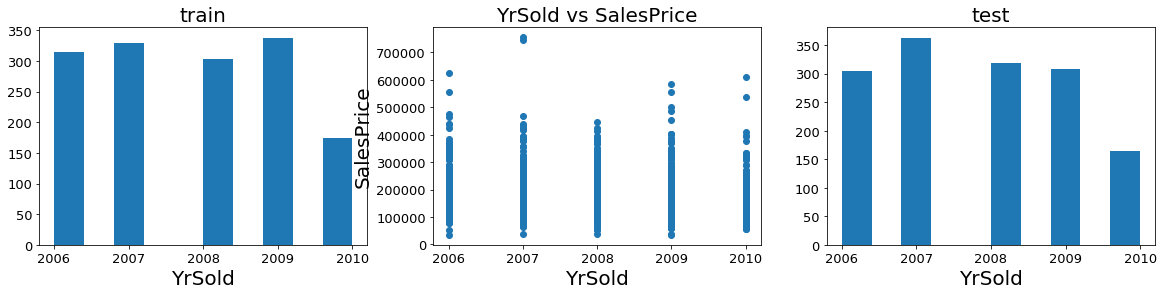

In [75]:
k = k +1
num_analysis(i=k)

    We have already made feature home age while sold using YrSold, so you should remove YrSold feature

    More to come...
    
    Stay tuned!

If You found this kernel helpful to you, Please upvote it. And also If you found any wrong information in kernel, Please comment it.
    
    Thanks for reading!